# Logistic regression is a classification algorithm, while linear regression is a regression algorithm. In this exercise, we will be working with linear regression, which is used to predict continuous values. The goal of linear regression is to find the best-fitting line that describes the relationship between the dependent variable (the variable we want to predict) and the independent variables (the variables we use to make predictions).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set()

# Load the data from a .csv in the same folder

In [3]:
raw_data = pd.read_csv('admittance.csv')
# Let's explore the top 5 rows of the df
raw_data.head()

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No


# Describe the data

In [4]:
raw_data.describe()

,SAT
count,168.000000
mean,1695.273810
std,183.019017
min,1334.000000
25%,1547.500000
50%,1691.500000
75%,1844.500000
max,2050.000000


# Change the column names to something more intuitive

In [5]:
data = raw_data.copy()
data['Admitted'] = data['Admitted'].map({'No': 0, 'Yes': 1})
data

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0
...,...,...
163,1722,1
164,1750,1
165,1555,0
166,1524,0


# Declare the dependent and the independent variables

In [6]:
y = data['Admitted'] # dependent variable
x1 = data['SAT'] # independent variable

# Plot the data

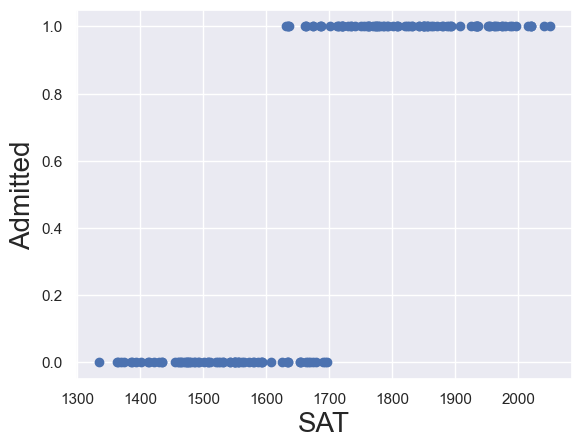

In [7]:
plt.scatter(x1, y, color='C0')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

# Plot the regression line

const   -3.251859
SAT      0.002248
dtype: float64
-3.251858542650689 0.0022482399779685663


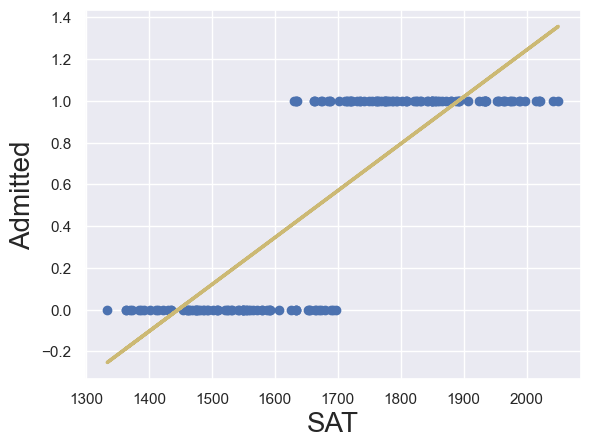

In [8]:
x = sm.add_constant(x1)
reg_lin = sm.OLS(y, x)
result_line = reg_lin.fit()
plt.scatter(x1, y, color='C0')
print(result_line.params)
print(result_line.params['const'], result_line.params['SAT'])
y_hat =  x1 * result_line.params['SAT']  + result_line.params['const']
plt.plot(x1, y_hat, lw = 2.5, color='C8')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

# Plot with logistic regression

Optimization terminated successfully.
         Current function value: 0.137766
         Iterations 10
const   -69.912802
SAT       0.042005
dtype: float64


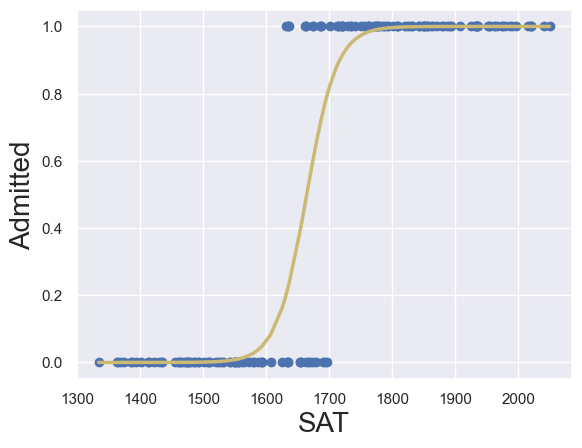

In [9]:
log_reg = sm.Logit(y, x)
result_log = log_reg.fit()
print(result_log.params)
def f(input_data, b0, b1):
    return np.array(np.exp(b0 + b1 * input_data) / (1 + np.exp(b0 + b1 * input_data)))
f_sorted = np.sort(f(x1, result_log.params['const'], result_log.params['SAT']))
x1_sorted = np.sort(np.array(x1))
plt.scatter(x1, y, color='C0')
plt.plot(x1_sorted, f_sorted, lw = 2.5, color='C8')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

In [10]:
# Accuracy of the model

In [11]:
result_log.pred_table()

array([[67.,  7.],
       [ 7., 87.]])

In [12]:
cm_df = pd.DataFrame(result_log.pred_table())
cm_df.columns = ['Predicted 0', 'Predicted 1']
cm_df = cm_df.rename(index={0: 'Actual 0', 1: 'Actual 1'})
cm_df

,Predicted 0,Predicted 1
Actual 0,67.0,7.0
Actual 1,7.0,87.0


In [13]:
cm = np.array(cm_df)
accuracy_train = (cm[0,0] + cm[1,1]) / cm.sum()
accuracy_train

np.float64(0.9166666666666666)